In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import numpy as np

# Getdata

In [4]:
def load_housing_data():
    tarball_path = Path("datasets/house_prices_dataset.csv")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        #url ="https://github.com/JoannaBroniarek/House-Prices-Advanced-Regression-Techniques/blob/master/dane/train.csv"
    url ="https://raw.githubusercontent.com/JoannaBroniarek/House-Prices-Advanced-Regression-Techniques/master/dane/train.csv"
    data = pd.read_csv(url)
    data.to_csv(tarball_path)
    return data
    

In [5]:
data = load_housing_data()

In [4]:
type(data)

pandas.core.frame.DataFrame

In [5]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


| Column           | Type       | Description |
|------------------|------------|-------------|
| Id               | int        | Unique ID for each house |
| MSSubClass       | int        | Building class |
| MSZoning         | categorical| General zoning classification |
| LotFrontage      | float      | Linear feet of street connected to property |
| LotArea          | int        | Lot size in square feet |
| Street           | categorical| Type of road access (Pave, Grvl) |
| Alley            | categorical| Type of alley access |
| LotShape         | categorical| General shape of property (Reg, IR1, IR2, IR3) |
| LandContour      | categorical| Flatness of property |
| Utilities        | categorical| Utilities available (AllPub, NoSeWa, etc.) |
| LotConfig        | categorical| Lot configuration (Inside, Corner, CulDSac, FR2, FR3) |
| LandSlope        | categorical| Slope of property (Gtl, Mod, Sev) |
| Neighborhood     | categorical| Physical location within Ames city limits |
| Condition1       | categorical| Proximity to main road or railroad |
| Condition2       | categorical| Proximity to second condition (less common) |
| BldgType         | categorical| Type of dwelling (1Fam, 2FmCon, Duplex, etc.) |
| HouseStyle       | categorical| Style of dwelling (1Story, 2Story, SFoyer, SLvl, etc.) |
| OverallQual      | int        | Overall material and finish (1=Poor … 10=Excellent) |
| OverallCond      | int        | Overall condition (1=Poor … 10=Excellent) |
| YearBuilt        | int        | Original construction year |
| YearRemodAdd     | int        | Remodel year (same as YearBuilt if no remodel) |
| RoofStyle        | categorical| Type of roof (Gable, Hip, Mansard, etc.) |
| RoofMatl         | categorical| Roof material |
| Exterior1st      | categorical| Exterior covering on house |
| Exterior2nd      | categorical| Exterior covering on house (if different) |
| MasVnrType       | categorical| Masonry veneer type |
| MasVnrArea       | float      | Masonry veneer area in square feet |
| ExterQual        | categorical| Evaluates exterior material quality |
| ExterCond        | categorical| Evaluates present condition of material |
| Foundation       | categorical| Type of foundation |
| BsmtQual         | categorical| Basement height quality |
| BsmtCond         | categorical| Basement condition |
| BsmtExposure     | categorical| Walkout or garden level exposure |
| BsmtFinType1     | categorical| Quality of basement finished area type 1 |
| BsmtFinSF1       | int        | Type 1 finished square feet |
| BsmtFinType2     | categorical| Quality of basement finished area type 2 |
| BsmtFinSF2       | int        | Type 2 finished square feet |
| BsmtUnfSF        | int        | Unfinished square feet of basement |
| TotalBsmtSF      | int        | Total square feet of basement |
| Heating          | categorical| Type of heating (GasA, GasW, etc.) |
| HeatingQC        | categorical| Heating quality and condition |
| CentralAir       | categorical| Central air conditioning (Y/N) |
| Electrical       | categorical| Electrical system (SBrkr, FuseF, etc.) |
| 1stFlrSF         | int        | First floor square feet |
| 2ndFlrSF         | int        | Second floor square feet |
| LowQualFinSF     | int        | Low quality finished square feet (all floors) |
| GrLivArea        | int        | Above grade living area square feet |
| BsmtFullBath     | int        | Basement full bathrooms |
| BsmtHalfBath     | int        | Basement half bathrooms |
| FullBath         | int        | Full bathrooms above grade |
| HalfBath         | int        | Half bathrooms above grade |
| BedroomAbvGr     | int        | Bedrooms above ground |
| KitchenAbvGr     | int        | Kitchens above ground |
| KitchenQual      | categorical| Kitchen quality |
| TotRmsAbvGrd     | int        | Total rooms above ground (excluding bathrooms) |
| Functional       | categorical| Home functionality (Typ, Min1, Min2, Mod, Maj1, Maj2, Sev, Sal) |
| Fireplaces       | int        | Number of fireplaces |
| FireplaceQu      | categorical| Fireplace quality |
| GarageType       | categorical| Garage location (Attchd, Detchd, BuiltIn…) |
| GarageYrBlt      | float      | Year garage was built |
| GarageFinish     | categorical| Interior finish (Fin, RFn, Unf, NA) |
| GarageCars       | int        | Size of garage in car capacity |
| GarageArea       | int        | Size in square feet |
| GarageQual       | categorical| Garage quality |
| GarageCond       | categorical| Garage condition |
| PavedDrive       | categorical| Paved driveway (Y, P, N) |
| WoodDeckSF       | int        | Wood deck area in square feet |
| OpenPorchSF      | int        | Open porch area in square feet |
| EnclosedPorch    | int        | Enclosed porch area in square feet |
| 3SsnPorch        | int        | Three season porch area in square feet |
| ScreenPorch      | int        | Screen porch area in square feet |
| PoolArea         | int        | Pool area in square feet |
| PoolQC           | categorical| Pool quality |
| Fence            | categorical| Fence quality (GdPrv, MnPrv, etc.) |
| MiscFeature      | categorical| Miscellaneous feature (Elev, Gar2, Shed, etc.) |
| MiscVal          | int        | Value of miscellaneous feature in dollars |
| MoSold           | int        | Month sold (1–12) |
| YrSold           | int        | Year sold (YYYY) |
| SaleType         | categorical| Type of sale (WD, CWD, New, COD, etc.) |
| SaleCondition    | categorical| Condition of sale (Normal, Abnormal, AdjLand, etc.) |
| SalePrice        | int        | Target variable – sale price in dollars |


In [6]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
data.isna().sum()[lambda x: x>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [9]:
print(f"MiscFeature-1406 : {data['MiscFeature'].dtypes}")
print(f"Fence-1179 : {data['Fence'].dtypes}")
print(f"PoolQC-1453 : {data['PoolQC'].dtypes}")
print(f"Alley-1369 : {data['Alley'].dtypes}")
print(f"MasVnrType-872 : {data['MasVnrType'].dtypes}")
print(f"FireplaceQu-690 : {data['FireplaceQu'].dtypes}")

MiscFeature-1406 : object
Fence-1179 : object
PoolQC-1453 : object
Alley-1369 : object
MasVnrType-872 : object
FireplaceQu-690 : object


In [10]:
data['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

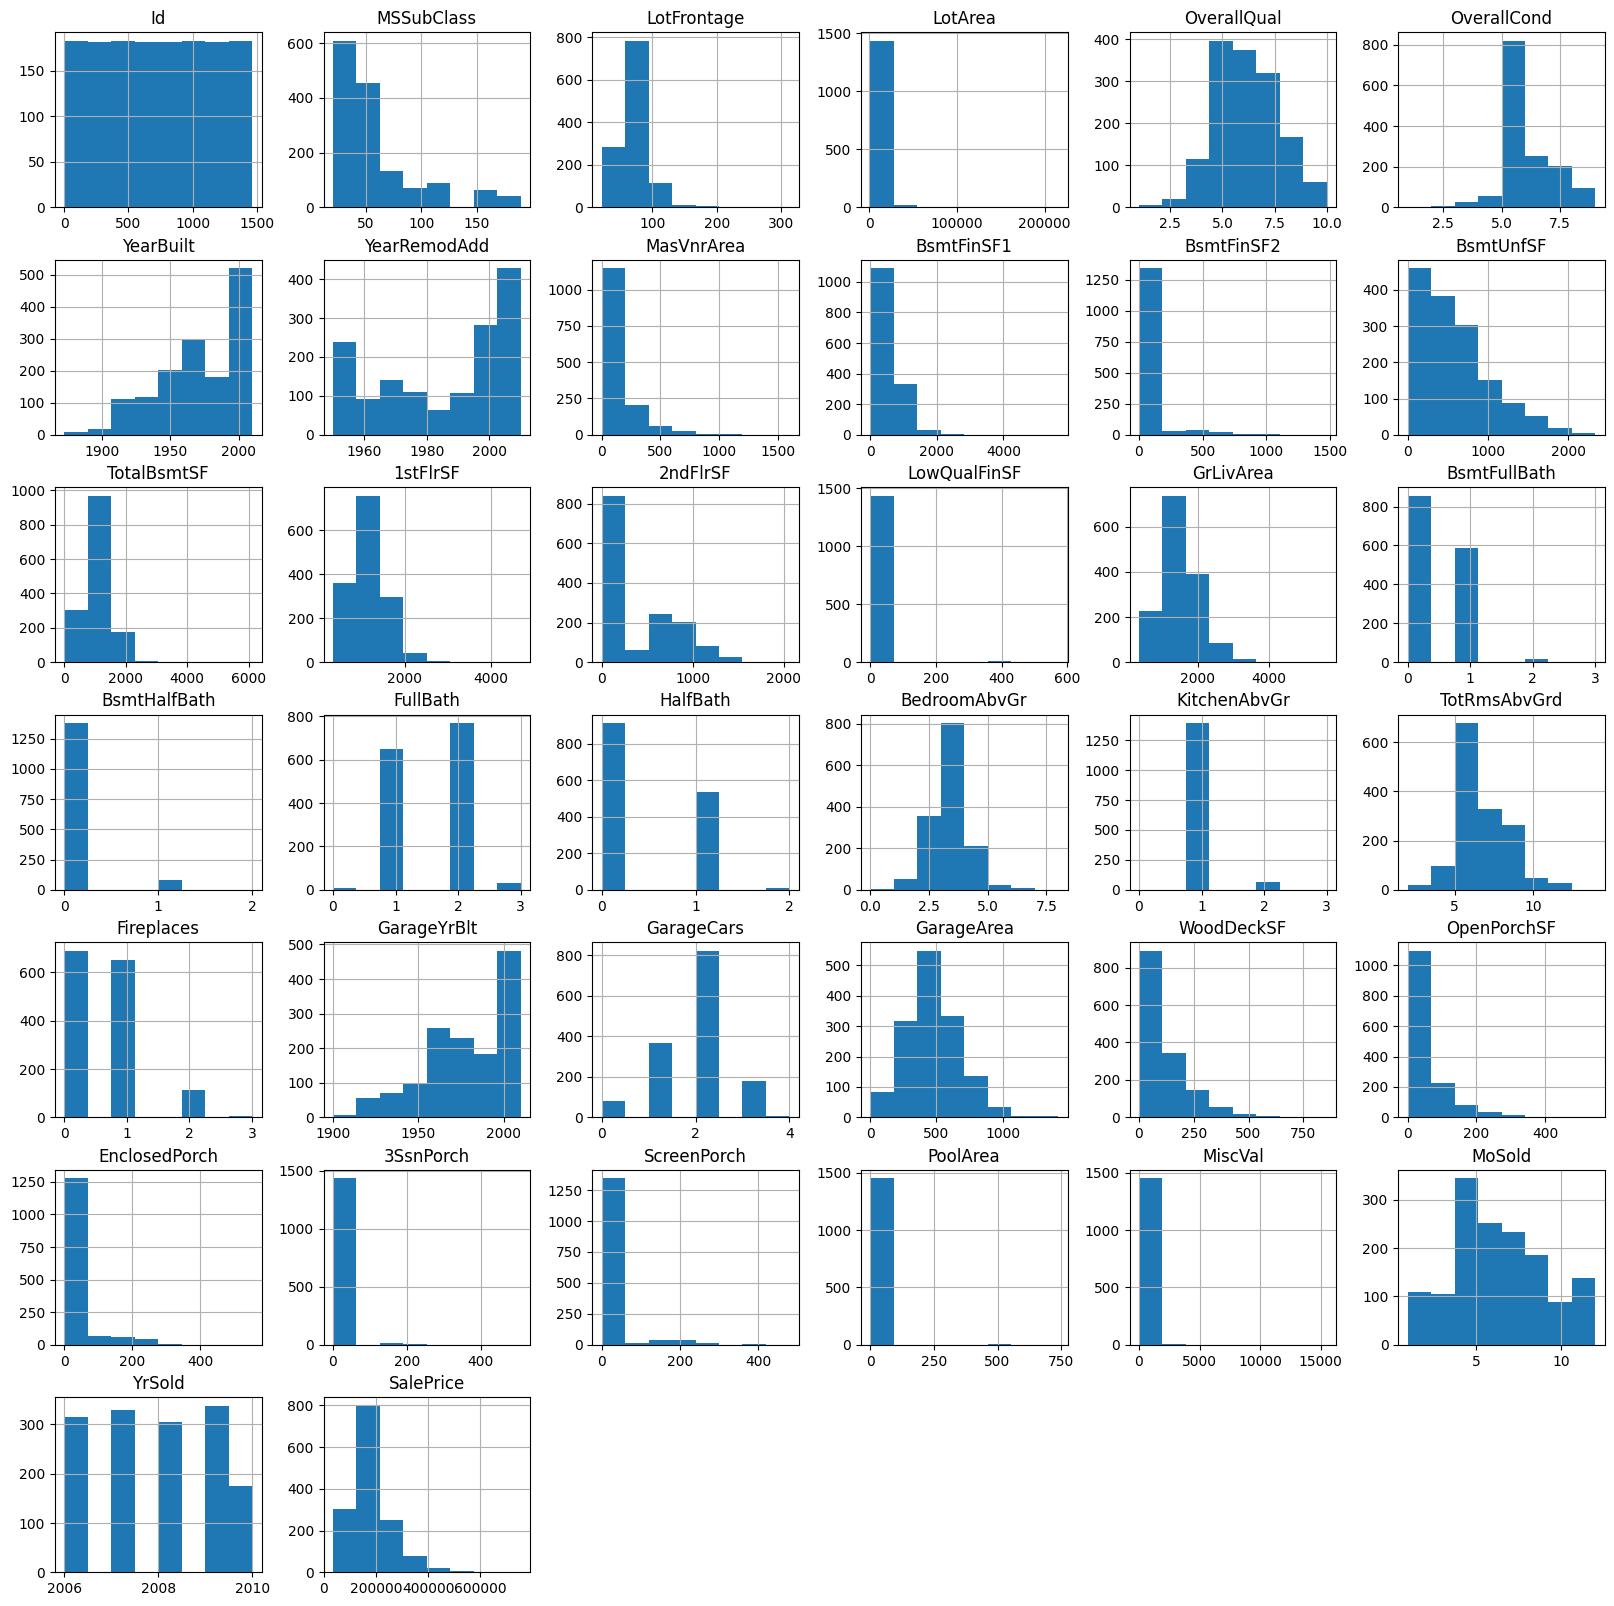

In [11]:
data.hist(bins=8, figsize=(20, 20))
plt.show()

In [12]:
data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [13]:
data['SalePrice'].value_counts()

SalePrice
140000    20
135000    17
145000    14
155000    14
190000    13
          ..
223000     1
257000     1
282922     1
193879     1
137450     1
Name: count, Length: 663, dtype: int64

In [14]:
data['Id'].describe()

count    1460.000000
mean      730.500000
std       421.610009
min         1.000000
25%       365.750000
50%       730.500000
75%      1095.250000
max      1460.000000
Name: Id, dtype: float64

In [15]:
data['PoolArea'].describe()

count    1460.000000
mean        2.758904
std        40.177307
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       738.000000
Name: PoolArea, dtype: float64

In [16]:
data['PoolArea'].value_counts()

PoolArea
0      1453
512       1
648       1
576       1
555       1
480       1
519       1
738       1
Name: count, dtype: int64

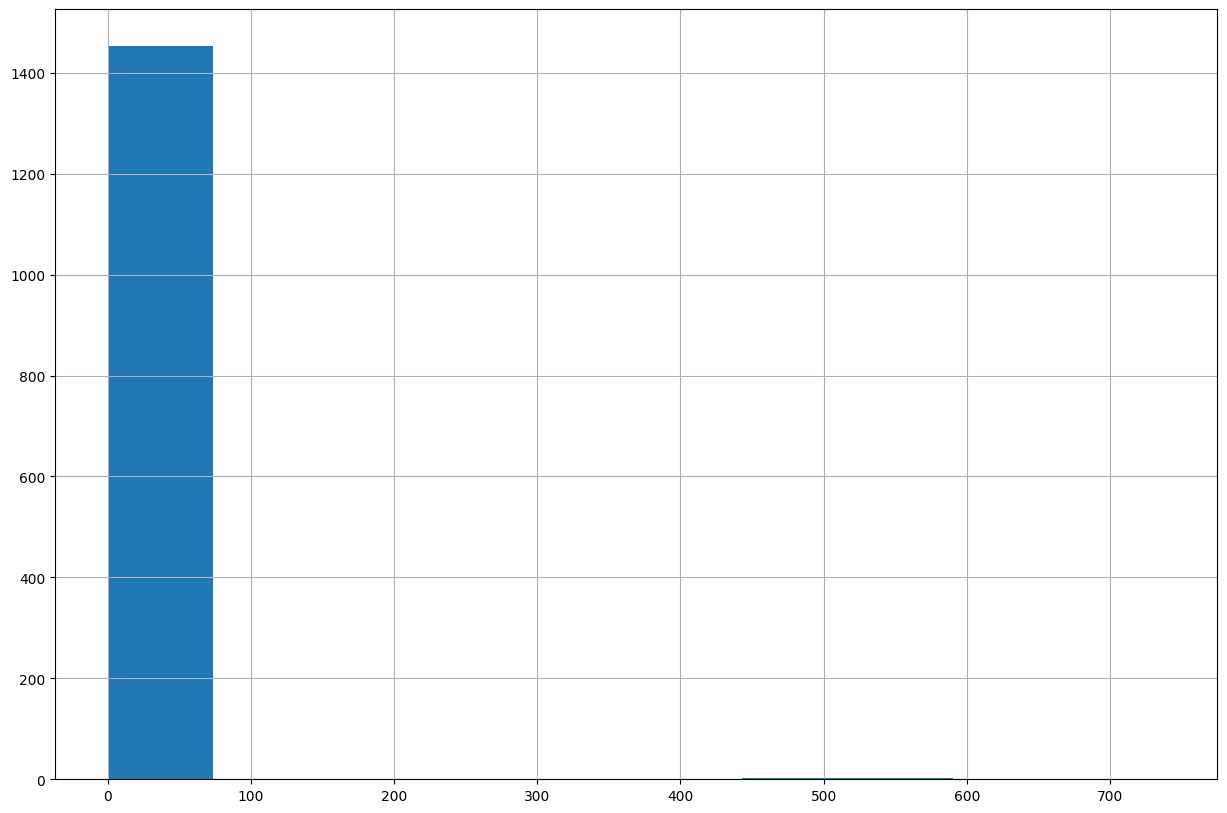

In [17]:
data['PoolArea'].hist(bins=10, figsize=(15, 10))
plt.show()

## Create a Test Set

In [18]:
np.random.seed(42)

In [9]:
def shuffle_and_split_data(data, test_ratio):
    np.random.seed(42)
    random_index = np.random.permutation(len(data))
    print(random_index)
    test_set_size = int(len(data) * test_ratio)
    test_indices= random_index[:test_set_size]
    train_indices = random_index[test_set_size:]
    return data.iloc[test_indices],data.iloc[train_indices]

if you run the program again, it will
generate a different test set! Over time,
> One solution is to save the test set on the first run and then load it in
subsequent runs.

> Another option is to set the random number generator’s
seed (e.g., with np.random.seed(42)) before calling
np.random.permutation() so that it always generates the same
shuffled indices.

However, both these solutions will break the next time you fetch an updated
dataset.

In [10]:
test_set,train_set = shuffle_and_split_data(data, 0.2)
print(len(train_set))

print(len(test_set))


[ 892 1105  413 ... 1294  860 1126]
1168
292


In [21]:
from zlib import crc32
def is_id_in_test_set(id,test_ratio):
    return crc32(np.int64(id)) <= test_ratio *2**32

def split_data_with_id_hash(data,test_ratio,column):
    ids = data[column]
    in_test_set = ids.apply(lambda id_ :is_id_in_test_set(id_,test_ratio))
    return data.iloc[in_test_set],data.iloc[~in_test_set]

📝 Simple Summary of train_test_split():

- The Scikit-Learn function train_test_split() is the standard, easy way to split datasets (like your features and labels) into training and testing subsets.

>It is essentially a more powerful version of a basic split function, offering two main advantages:

- Reproducibility (Random Seed): It includes a random_state parameter. Setting this value (e.g., random_state=42) ensures that you get the exact same split every time you run the code.

- Synchronized Splitting: You can pass multiple datasets (e.g., your input features and their corresponding target labels) to the function, and it will automatically split them using the same indices. This keeps your features and labels matched correctly in the resulting train and test sets.

In [11]:
from sklearn.model_selection import train_test_split
train_set,test_set = train_test_split(data,test_size=0.2,random_state=42)

>Why Simple Random Sampling Can Fail?

If a **dataset is not large enough**, purely random sampling can accidentally create a sample that is not representative of the overall population, leading to sampling bias.

Example: If you sample 1,000 people from the US population (51.1% female, 48.9% male) purely at random, there is a risk (about 10.7%) of getting a test set with a significantly skewed gender ratio (e.g., less than 48.5% female). This skew can bias the survey results.

>Stratified Sampling:

- To avoid sampling bias, researchers and data scientists use stratified sampling:

Definition: The population is divided into uniform groups called strata.

Goal: To ensure the sample (test set) is representative, the correct proportion of instances is sampled from each stratum.


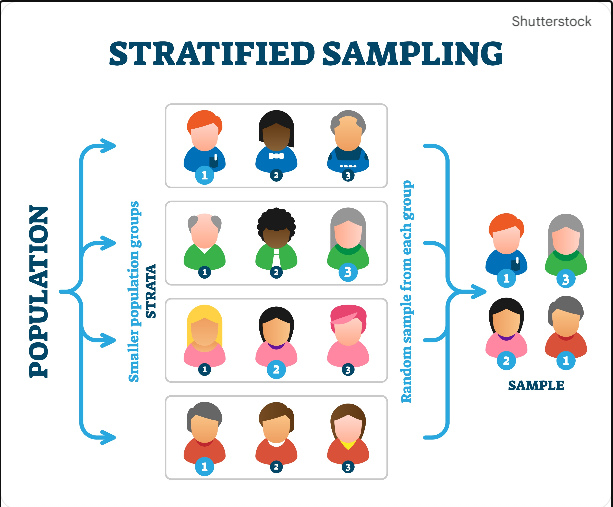

In [23]:
data['SalePrice'].value_counts()

SalePrice
140000    20
135000    17
145000    14
155000    14
190000    13
          ..
223000     1
257000     1
282922     1
193879     1
137450     1
Name: count, Length: 663, dtype: int64

<Axes: >

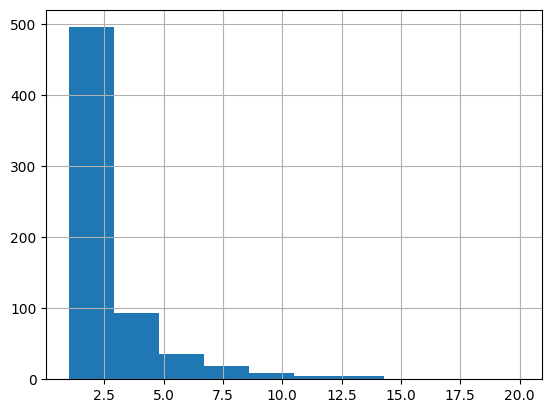

In [24]:
data['SalePrice'].value_counts().hist()


In [25]:
SalePrice_cat = pd.cut(data['SalePrice'],bins=[])

In [26]:
SalePrice_cat

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
1455    NaN
1456    NaN
1457    NaN
1458    NaN
1459    NaN
Name: SalePrice, Length: 1460, dtype: category
Categories (0, interval[int64, right]): []

In [27]:
from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(test_size=0.2,random_state=42)
strat_split = []
for train_idx,test_idx in splitter.split(data,SalePrice_cat):
    pass

ValueError: Input contains NaN

# Explore and Visualize the Data to Gain Insights

In [12]:
housing = train_set.copy()

In [ ]:
housing.shape

(1168, 81)

In [ ]:
housing.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
254,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1066,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
638,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
799,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
380,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


## Look for Correlations

> The correlation coefficient only measures linear correlations (“as x goes up, y generally
goes up/down”)

In [ ]:
corr_matrix = housing.select_dtypes(include='number').corr()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.002216,-0.004147,-0.033411,-0.017880,0.029571,-0.022142,-0.032560,-0.023680,-0.011790,...,-0.005502,0.012795,0.007900,-0.049430,-0.000534,0.055850,-0.006444,0.013713,0.004211,-0.019643
MSSubClass,0.002216,1.000000,-0.371269,-0.116501,0.029719,-0.052768,-0.001928,0.036081,-0.013491,-0.080944,...,-0.022712,-0.011753,-0.008086,-0.058672,-0.033155,0.003578,-0.006216,-0.014139,-0.028758,-0.088081
LotFrontage,-0.004147,-0.371269,1.000000,0.427009,0.249726,-0.051725,0.123858,0.091253,0.223236,0.236182,...,0.077670,0.143753,-0.004749,0.081709,0.052087,0.245424,0.000787,0.023850,0.003097,0.330066
LotArea,-0.033411,-0.116501,0.427009,1.000000,0.102088,0.001625,0.013541,0.017216,0.125634,0.224270,...,0.177537,0.086320,-0.024948,0.023200,0.046353,0.086463,0.038358,0.003973,-0.005098,0.266204
OverallQual,-0.017880,0.029719,0.249726,0.102088,1.000000,-0.087599,0.558124,0.538251,0.416085,0.204864,...,0.232991,0.288691,-0.121967,0.025278,0.060840,0.079182,-0.032040,0.053355,-0.017635,0.785555
OverallCond,0.029571,-0.052768,-0.051725,0.001625,-0.087599,1.000000,-0.386268,0.055034,-0.143063,-0.043388,...,-0.007352,-0.029882,0.067696,0.017296,0.057537,-0.007496,0.077016,0.007975,0.023782,-0.074391
YearBuilt,-0.022142,-0.001928,0.123858,0.013541,0.558124,-0.386268,1.000000,0.587311,0.318101,0.223348,...,0.217083,0.176241,-0.392513,0.029117,-0.047356,0.004362,-0.033683,0.006257,0.000670,0.516501
YearRemodAdd,-0.032560,0.036081,0.091253,0.017216,0.538251,0.055034,0.587311,1.000000,0.159416,0.104648,...,0.211789,0.224053,-0.205697,0.042385,-0.060476,0.011388,-0.006076,0.025142,0.046533,0.508593
MasVnrArea,-0.023680,-0.013491,0.223236,0.125634,0.416085,-0.143063,0.318101,0.159416,1.000000,0.244347,...,0.165278,0.120480,-0.128226,0.031382,0.058113,0.021877,-0.031668,0.002810,0.005671,0.459123
BsmtFinSF1,-0.011790,-0.080944,0.236182,0.224270,0.204864,-0.043388,0.223348,0.104648,0.244347,1.000000,...,0.189172,0.092833,-0.115216,0.027128,0.054527,0.165951,0.004168,-0.011884,0.032167,0.359460


In [ ]:
corr_matrix['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.785555
GrLivArea        0.695652
GarageCars       0.640991
GarageArea       0.624139
TotalBsmtSF      0.597766
1stFlrSF         0.587883
FullBath         0.552546
TotRmsAbvGrd     0.520388
YearBuilt        0.516501
YearRemodAdd     0.508593
GarageYrBlt      0.480351
MasVnrArea       0.459123
Fireplaces       0.457549
BsmtFinSF1       0.359460
LotFrontage      0.330066
WoodDeckSF       0.329843
2ndFlrSF         0.314030
OpenPorchSF      0.299969
HalfBath         0.280481
LotArea          0.266204
BsmtFullBath     0.226346
BsmtUnfSF        0.222487
BedroomAbvGr     0.156211
ScreenPorch      0.119172
PoolArea         0.115630
3SsnPorch        0.051532
MoSold           0.041890
BsmtFinSF2      -0.005731
YrSold          -0.009099
LowQualFinSF    -0.011189
Id              -0.019643
MiscVal         -0.020179
BsmtHalfBath    -0.048346
OverallCond     -0.074391
MSSubClass      -0.088081
KitchenAbvGr    -0.142785
EnclosedPorch   -0.149532
Name: SalePr

In [ ]:
attribute = ['OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF','1stFlrSF','FullBath','BsmtFullBath']
corr_matrix[attribute]
# GrLivArea	0.581783
# TotRmsAbvGrd 0.820718
# GarageArea 0.882550
# 1stFlrSF	0.827382
# TotalBsmtSF	0.827382
# GrLivArea	0.617812
#BsmtFinSF1	0.648970


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,BsmtFullBath
Id,-0.017880,0.015503,0.019903,0.029607,-0.018200,0.012159,0.005492,-0.002575
MSSubClass,0.029719,0.088452,-0.040787,-0.096140,-0.244521,-0.251166,0.152088,-0.002678
LotFrontage,0.249726,0.392216,0.276314,0.336914,0.394947,0.450932,0.188595,0.096045
LotArea,0.102088,0.266187,0.151803,0.179124,0.262559,0.298230,0.117296,0.168373
OverallQual,1.000000,0.581783,0.587487,0.550476,0.529557,0.463751,0.539661,0.091070
OverallCond,-0.087599,-0.062510,-0.173115,-0.139431,-0.171633,-0.133805,-0.181278,-0.052605
YearBuilt,0.558124,0.171195,0.525740,0.466610,0.391372,0.271891,0.460457,0.172935
YearRemodAdd,0.538251,0.281727,0.414912,0.364826,0.287686,0.233857,0.449488,0.109849
MasVnrArea,0.416085,0.376243,0.368440,0.383544,0.380961,0.362714,0.269270,0.088614
BsmtFinSF1,0.204864,0.200873,0.199566,0.280523,0.517577,0.437983,0.029938,0.648970


The high correlation signifies that the purpose of having a large, high-quality finished area (BsmtFinSF1) is usually to create functional living space, and functional living space demands convenient, full bathing facilities (BsmtFullBath).

- Explanation of BsmtFinSF1BsmtFinSF1 stands for:

 Basement Finished Square Footage Type 1.It represents the area of the basement that is considered high-quality, primary finished space.
 1.  What does "Type 1" mean?
 
 The Ames dataset categorizes finished basement space into two types based on quality and function:
 
 Type 1 (Fin): This is the best quality finished area. It is typically designed for living purposes, like a family room, recreation room, home office, or a legal bedroom. This space is often comparable in finish quality to the main floor living areas.
 
 Type 2 (Fin): This is the lower quality finished area (BsmtFinSF2). This space is usually reserved for secondary functions, like storage, workshops, or a low-traffic utility area.

 2. Analytical ImportanceImpact on Price: 
 
 This is a crucial feature because finished living space in the basement adds significant monetary value to a home.
 
  The higher the BsmtFinSF1 value, the more valuable the basement is considered.
  
  - Distinction from Total Area:
  
  It is different from TotalBsmtSF (which is the entire basement footprint, finished and unfinished).
  
  It is different from BsmtUnfSF (which is the area that is completely unfinished).
  
  3. Summary of Basement BreakdownYou can think of the total basement area as being split into three components:$$TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF$$FeatureDescriptionValue ImplicationBsmtFinSF1Primary Finished Area (High Quality)Adds high value (e.g., a family room).BsmtFinSF2Secondary Finished Area (Low Quality)Adds some value (e.g., a workshop).BsmtUnfSFUnfinished AreaLowest value (used for storage/utilities).

In [ ]:
corr_matrix['SalePrice'].sort_values(ascending=False)

In [ ]:
housing['OverallCond'].value_counts().sort_values()

In [ ]:
housing['OverallQual'].value_counts().sort_values()
housing['MSSubClass'].value_counts()
housing['LotArea'].value_counts()
housing['MasVnrArea'].value_counts()
housing['BsmtFinSF2'].value_counts()
housing['HouseStyle'].value_counts()

In [ ]:
corr_matrix['SalePrice'].sort_values(ascending=False)
corr_matrix['SalePrice']['MSSubClass']
corr_matrix['SalePrice']['LotArea']
corr_matrix['SalePrice']['OverallQual']
corr_matrix['SalePrice']['MasVnrArea']
corr_matrix['SalePrice']['BsmtFinSF2']
corr_matrix['SalePrice']['MoSold']
# corr_matrix['SalePrice']['MiscVal']

In [ ]:
from pandas.plotting import scatter_matrix
attribute = ['OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF','1stFlrSF']

scatter_matrix(housing[attribute], figsize=(200, 200))
plt.show()

<Axes: ylabel='SalePrice'>

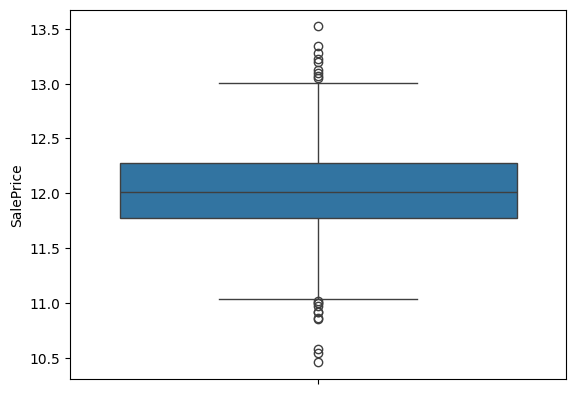

In [ ]:
import seaborn as sns
sns.boxplot((housing['SalePrice']))


In [ ]:
sns.boxplot(np.log(housing['SalePrice']))


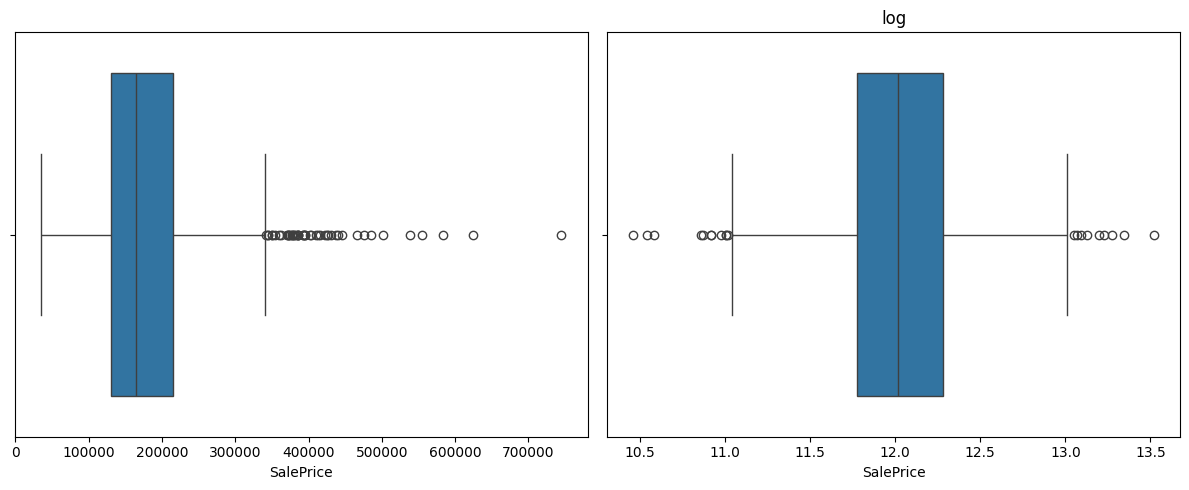

In [ ]:
# --- PLOT 1: Histogram on the left (axes[0]) ---
# 1. Create a figure (the entire canvas) and 2 axes (the plots)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5)) 
# figsize=(12, 5) makes the overall canvas 12 inches wide and 5 inches tall
sns.boxplot(x=housing['SalePrice'], ax=axes[0])


# --- PLOT 2: Scatter Plot on the right (axes[1]) ---
sns.boxplot(x=np.log(housing['SalePrice']), ax=axes[1])
axes[1].set_title('log')

# Optional: Add padding between plots for readability
plt.tight_layout()

# Display the final combined figure
plt.show()

<Axes: ylabel='OverallQual'>

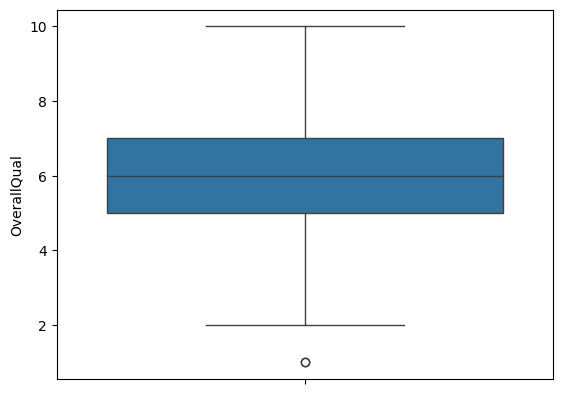

In [ ]:
sns.boxplot(housing['OverallQual'])

<Axes: xlabel='SalePrice', ylabel='Count'>

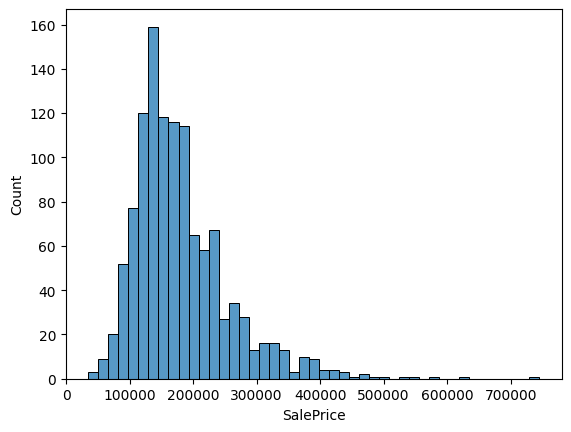

In [ ]:
# The Density Plot of SalePrice
sns.histplot(housing['SalePrice'])

In [ ]:
#The featutres with height correlation with SalesPrice
# OverallQual      0.785555
# GrLivArea        0.695652
# GarageCars       0.640991
# GarageArea       0.624139
# TotalBsmtSF      0.597766
# 1stFlrSF         0.587883
# FullBath         0.552546
# TotRmsAbvGrd     0.520388
# YearBuilt        0.516501
# YearRemodAdd     0.508593
print(f"OverallQual : {housing['OverallQual'].skew()}")
print(f"GrLivArea : {housing['GrLivArea'].skew()}")
print(f"GarageCars : {housing['GarageCars'].skew()}")
print(f"GarageArea : {housing['GarageArea'].skew()}")
print(f"TotalBsmtSF : {housing['TotalBsmtSF'].skew()}")
print(f"1stFlrSF : {housing['1stFlrSF'].skew()}")
print(f"FullBath : {housing['FullBath'].skew()}")
print(f"TotRmsAbvGrd : {housing['TotRmsAbvGrd'].skew()}")
print(f"YearBuilt : {housing['YearBuilt'].skew()}")
print(f"YearRemodAdd : {housing['YearRemodAdd'].skew()}")

OverallQual : 0.19657464137878028
GrLivArea : 1.4251389521467905
GarageCars : -0.38973204730819544
GarageArea : 0.10910988502757094
TotalBsmtSF : 1.7238807131397176
1stFlrSF : 1.422161836606057
FullBath : 0.038168623718733356
TotRmsAbvGrd : 0.6873364344880455
YearBuilt : -0.6234042550450195
YearRemodAdd : -0.508066741226424


In [ ]:
skewness_results = housing.select_dtypes(include=np.number).apply(lambda x: x.skew())

highly_skewed_important_features = skewness_results[
    (skewness_results > 1.0) & 
    (abs(corr_matrix['SalePrice']) > 0.2)
]

In [ ]:
highly_skewed_important_features

LotFrontage     2.406787
LotArea        11.958088
MasVnrArea      2.286423
BsmtFinSF1      1.862132
TotalBsmtSF     1.723881
1stFlrSF        1.422162
GrLivArea       1.425139
WoodDeckSF      1.587330
OpenPorchSF     2.331890
SalePrice       1.743129
dtype: float64

In [ ]:
print(housing['SalePrice'].skew())
print(np.log(housing['SalePrice']).skew())

1.743128561420854
0.12487950942382703


In [ ]:
#Check YearBuilt  feature
data['YearBuilt'].apply(lambda x : x>2025).sum()
data['YearRemodAdd'].apply(lambda x : x>2025).sum()

np.int64(0)

In [ ]:
((data['YearBuilt']) - data['YearRemodAdd']>0).sum()

np.int64(0)

In [ ]:
housing = train_set.drop("SalePrice", axis=1)
housing_labels = train_set["SalePrice"].copy()

# Prepare the Data for Machine Learning Algorithms

## Drop Unuseful Fratures

**Removing columns that contain the same value in 100%**

According to basic statistics provided on Kaggle competiton website, the columns Street and Utilities contain only one value "Pave" and "AllPub" respectively

In [ ]:
print(housing['Utilities'].value_counts())
print(housing['Street'].value_counts())

Utilities
AllPub    1167
NoSeWa       1
Name: count, dtype: int64
Street
Pave    1164
Grvl       4
Name: count, dtype: int64


**💡 General Rule for Removal**

The main reason to remove a feature based on its value counts is Low Variance/High Uniformity.A feature where $99\%$ or more of the values fall into a single category provides negligible information to a predictive model and only adds unnecessary complexity and computational load.In summary, you should confidently remove the Utilities column, and it is highly recommended to remove the Street column as well.

In [ ]:
housing = housing.drop(["Street", "Utilities"], axis=1)

Columns to Drop (More Than 90% Missing)

In [44]:
housing.shape

(1168, 81)

In [49]:
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley']
print(f"Types : \n{housing[cols_to_drop].dtypes}")
print(f"% of NAN : \n{housing[cols_to_drop].isna().sum()/housing.shape[0]}")


Types : 
PoolQC         object
MiscFeature    object
Alley          object
dtype: object
% of NAN : 
PoolQC         0.994863
MiscFeature    0.960616
Alley          0.936644
dtype: float64


In [ ]:
# List of columns identified as having > 90% missing values
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley']
housing = housing.drop(columns=cols_to_drop,inplace=True)

The Fence feature in the Ames Housing Dataset is a categorical variable that describes the quality of the fence around the property.It is often a crucial column for data cleaning because of how missing values are interpreted.

Value   Meaning

GdPrv   Good Privacy Fence

MnPrvMinimum Privacy Fence

GdWoGood    Wood Fence

MnWwMinimum Wood/Wire Fence

NaN No  Fence

## Clean the Data

### ⚠️ Data Cleaning Warning: Outliers in GrLivArea

The dataset creator advises removing five specific observations that can severely distort model training, particularly for linear regression. These points fall into two categories:

> **Source Warning:** "There are five observations that an instructor may wish to remove from the data set before giving it to students... Three of them are true outliers (Partial Sales that likely don’t represent actual market values) and two of them are simply unusual sales (very large houses priced relatively appropriately). I would recommend removing any houses with more than **4000 square feet** from the data set (which eliminates these five unusual observations)..."

**Source:** [Ames, Iowa: The Most Comprehensive Housing Dataset Ever](https://jse.amstat.org/v19n3/decock.pdf)

**Action:** We will filter the dataset to remove any houses where the Above Ground Living Area (`GrLivArea`) is greater than 4000 sq ft.







In [ ]:
import seaborn as sns
# Visualize the Outliers 
sns.scatterplot(x=data['GrLivArea'], y=data['SalePrice'])
plt.title('SalePrice vs GrLivArea (Before Outlier Removal)')
plt.show() 

In [ ]:
data[data['GrLivArea'] > 4000]

In [ ]:
data_cleaned = data[data['GrLivArea'] < 4000].copy()

**Missing Not at Random (MNAR) - Categorical Features**

Handling MNAR in Data Science
Domain Knowledge is Key: As shown with the Ames housing data, the only reliable way to handle MNAR is to use domain knowledge to assign a meaningful, non-missing category (like "None" or 0) to the NaN values.

Modeling Difficulty: MNAR often requires complex statistical models or imputation techniques that model the missingness mechanism itself, making it the most challenging type of missing data to deal with correctly.

For these features, NaN means "None" (the absence of the feature, which is informative). 
We impute the NaNs with the string 'None'.

In [31]:
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [33]:
#data.isna().sum()[lambda x: x>0]
data.select_dtypes(np.number).isna().sum()[lambda x: x>0]

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

In [ ]:
# Categorical columns where NaN means 'None' (MNAR)
cols_fill_none_cat = [
    'FireplaceQu', 'Fence', 'MasVnrType',
    # Garage features
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    # Basement features
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]

In [ ]:
for cl in cols_fill_none_cat:
    print(housing[cl].value_counts())

FireplaceQu
Gd    305
TA    252
Fa     27
Ex     21
Po     16
Name: count, dtype: int64
Fence
MnPrv    128
GdPrv     50
GdWo      46
MnWw       9
Name: count, dtype: int64
MasVnrType
BrkFace    366
Stone      106
BrkCmn      13
Name: count, dtype: int64
GarageType
Attchd     693
Detchd     308
BuiltIn     74
Basment     16
CarPort      7
2Types       6
Name: count, dtype: int64
GarageFinish
Unf    480
RFn    339
Fin    285
Name: count, dtype: int64
GarageQual
TA    1050
Fa      36
Gd      13
Ex       3
Po       2
Name: count, dtype: int64
GarageCond
TA    1061
Fa      27
Gd       9
Po       5
Ex       2
Name: count, dtype: int64
BsmtQual
TA    521
Gd    493
Ex     97
Fa     29
Name: count, dtype: int64
BsmtCond
TA    1045
Gd      55
Fa      39
Po       1
Name: count, dtype: int64
BsmtExposure
No    769
Av    175
Gd    103
Mn     93
Name: count, dtype: int64
BsmtFinType1
Unf    345
GLQ    328
ALQ    178
BLQ    123
Rec    104
LwQ     62
Name: count, dtype: int64
BsmtFinType2
Unf    1009


In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer()
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)
# imputer.transform(housing_num)
housing_num = pd.DataFrame(
    imputer.transform(housing_num),
    columns=housing_num.columns,
    index=housing_num.index
)


In [ ]:
housing_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   float64
 1   MSSubClass     1168 non-null   float64
 2   LotFrontage    1168 non-null   float64
 3   LotArea        1168 non-null   float64
 4   OverallQual    1168 non-null   float64
 5   OverallCond    1168 non-null   float64
 6   YearBuilt      1168 non-null   float64
 7   YearRemodAdd   1168 non-null   float64
 8   MasVnrArea     1168 non-null   float64
 9   BsmtFinSF1     1168 non-null   float64
 10  BsmtFinSF2     1168 non-null   float64
 11  BsmtUnfSF      1168 non-null   float64
 12  TotalBsmtSF    1168 non-null   float64
 13  1stFlrSF       1168 non-null   float64
 14  2ndFlrSF       1168 non-null   float64
 15  LowQualFinSF   1168 non-null   float64
 16  GrLivArea      1168 non-null   float64
 17  BsmtFullBath   1168 non-null   float64
 18  BsmtHalfBat

In [ ]:
imputer.statistics_

array([7.30904966e+02, 5.68493151e+01, 7.03438486e+01, 1.06896421e+04,
       6.12157534e+00, 5.58476027e+00, 1.97096575e+03, 1.98489726e+03,
       1.03771945e+02, 4.46023973e+02, 4.51523973e+01, 5.70595034e+02,
       1.06177140e+03, 1.16935445e+03, 3.52351027e+02, 5.69606164e+00,
       1.52740154e+03, 4.25513699e-01, 5.73630137e-02, 1.57705479e+00,
       3.81849315e-01, 2.89041096e+00, 1.04794521e+00, 6.56164384e+00,
       6.18150685e-01, 1.97866214e+03, 1.78167808e+00, 4.76273973e+02,
       9.59469178e+01, 4.95787671e+01, 2.18390411e+01, 3.81250000e+00,
       1.54075342e+01, 2.95547945e+00, 5.12671233e+01, 6.35616438e+00,
       2.00781849e+03])

## Handling Text and Categorical Attributes

> If there are a limited number of possible values, each of
which represents a category. So this attribute is a categorical attribute.

Most machine learning algorithms prefer to work with numbers, so we need to convert
these categories from text to numbers.

In [13]:
housing_cat = housing.select_dtypes(np.object_)

In [ ]:
housing_cat

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
254,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1066,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
638,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,...,NaN,NaN,NaN,NaN,P,NaN,MnPrv,NaN,WD,Normal
799,RL,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Feedr,...,Detchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
380,RL,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1130,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,...,Detchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
1294,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,...,Detchd,Unf,TA,TA,N,NaN,NaN,NaN,WD,Normal
860,RL,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,GdPrv,NaN,WD,Normal


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
ordinalEncoder = OrdinalEncoder()
housing_cat_encoded = ordinalEncoder.fit_transform(housing_cat)

One issue with this representation is that ML algorithms will assume that
two nearby values are more similar than two distant values. This may be
fine in some cases (e.g., for ordered categories such as “bad”, “average”,
“good”, and “excellent”).


**To fix this issue, a common solution is**
 to create one binary attribute per category: one attribute equal to 1 when
the category is "<1H OCEAN" (and 0 otherwise), another attribute equal to
1 when the category is "INLAND" (and 0 otherwise), and so on. This is
called one-hot encoding, because only one attribute will be equal to 1 (hot),
while the others will be 0 (cold). The new attributes are sometimes called
dummy attributes. Scikit-Learn provides a OneHotEncoder class to
convert categorical values into one-hot vectors:

In [57]:
housing['Neighborhood'].value_counts()

Neighborhood
NAmes      181
CollgCr    115
OldTown     91
Edwards     87
Somerst     69
NWAmes      66
Gilbert     65
NridgHt     61
Sawyer      58
BrkSide     45
Crawfor     44
SawyerW     44
Mitchel     40
NoRidge     33
Timber      28
IDOTRR      26
SWISU       21
StoneBr     20
ClearCr     19
Blmngtn     15
BrDale      13
MeadowV     10
Veenker      9
NPkVill      7
Blueste      1
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import OneHotEncoder
oneHotEncoder = OneHotEncoder()
housing_cat_one_hot_encoded = oneHotEncoder.fit_transform(housing_cat)

>By default, the output of a OneHotEncoder is a SciPy sparse matrix,
instead of a NumPy array:

In [ ]:
housing_cat_one_hot_encoded.toarray()

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(1168, 265))

When we fit any Scikit-Learn estimator using a DataFrame, the estimator
stores the column names in the feature_names_in_ attribute. Scikit-
Learn then ensures that any DataFrame fed to this estimator after that (e.g.,
to transform() or predict()) has the same column names.

In [ ]:
oneHotEncoder.get_feature_names_out()
# Tells you the names of the new columns created by One-Hot Encoding. It combines the original name with the category

array(['MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL',
       'MSZoning_RM', 'Street_Grvl', 'Street_Pave', 'Alley_Grvl',
       'Alley_Pave', 'Alley_nan', 'LotShape_IR1', 'LotShape_IR2',
       'LotShape_IR3', 'LotShape_Reg', 'LandContour_Bnk',
       'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl',
       'Utilities_AllPub', 'Utilities_NoSeWa', 'LotConfig_Corner',
       'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3',
       'LotConfig_Inside', 'LandSlope_Gtl', 'LandSlope_Mod',
       'LandSlope_Sev', 'Neighborhood_Blmngtn', 'Neighborhood_Blueste',
       'Neighborhood_BrDale', 'Neighborhood_BrkSide',
       'Neighborhood_ClearCr', 'Neighborhood_CollgCr',
       'Neighborhood_Crawfor', 'Neighborhood_Edwards',
       'Neighborhood_Gilbert', 'Neighborhood_IDOTRR',
       'Neighborhood_MeadowV', 'Neighborhood_Mitchel',
       'Neighborhood_NAmes', 'Neighborhood_NPkVill',
       'Neighborhood_NWAmes', 'Neighborhood_NoRidge',
       'Neighborhood_NridgHt', '

In [ ]:
oneHotEncoder.feature_names_in_

array(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish',
       'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence',
       'MiscFeature', 'SaleType', 'SaleCondition'], dtype=object)

In [ ]:
oneHotEncoder.categories_

[array(['C (all)', 'FV', 'RH', 'RL', 'RM'], dtype=object),
 array(['Grvl', 'Pave'], dtype=object),
 array(['Grvl', 'Pave', nan], dtype=object),
 array(['IR1', 'IR2', 'IR3', 'Reg'], dtype=object),
 array(['Bnk', 'HLS', 'Low', 'Lvl'], dtype=object),
 array(['AllPub', 'NoSeWa'], dtype=object),
 array(['Corner', 'CulDSac', 'FR2', 'FR3', 'Inside'], dtype=object),
 array(['Gtl', 'Mod', 'Sev'], dtype=object),
 array(['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr',
        'Crawfor', 'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel',
        'NAmes', 'NPkVill', 'NWAmes', 'NoRidge', 'NridgHt', 'OldTown',
        'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber',
        'Veenker'], dtype=object),
 array(['Artery', 'Feedr', 'Norm', 'PosA', 'PosN', 'RRAe', 'RRAn', 'RRNe',
        'RRNn'], dtype=object),
 array(['Artery', 'Feedr', 'Norm', 'PosA', 'PosN', 'RRAe', 'RRAn', 'RRNn'],
       dtype=object),
 array(['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE'], dtype=objec

>Pandas has a function called get_dummies(), which also converts each
categorical feature into a one-hot representation, with one binary feature per
category

>the advantage of OneHotEncoder is that it remembers which
categories it was trained on. This is very important because once your
model is in production, it should be fed exactly the same features as during
training: no more, no less

- Difference?

>get_dummies() saw only two categories, so it
output two columns, whereas OneHotEncoder output one column per
learned category, in the right order.

>Moreover, if you feed
get_dummies() a DataFrame containing an unknown category (e.g., "
<2H OCEAN"), it will happily generate a column for i
But OneHotEncoder is smarter: it will detect the unknown category and
raise an exception.

🔹***TIP :***

***If a categorical attribute has a large number of possible categories*** (e.g., country code,
profession, species), then one-hot encoding will result in a large number of input
features. This may slow down training and degrade performance. If this happens, you
may want to replace the categorical input with useful numerical features related to the
categories: for example, you could replace the ocean_proximity feature with the
distance to the ocean (similarly, a country code could be replaced with the country’s
population and GDP per capita). Alternatively, you can use one of the encoders provided
by the category_encoders package on GitHub. Or, when dealing with neural
networks, you can replace each category with a learnable, low-dimensional vector called
an embedding.

In [ ]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "2h"]})
pd.get_dummies(df_test)


,ocean_proximity_2h,ocean_proximity_INLAND
0,False,True
1,True,False


In [ ]:

for col in housing_cat.columns:
    print(housing_cat[col].value_counts())

#Ordinal Encoder
# ExterQual - ExterCond - BsmtQual - BsmtCond - FireplaceQu - GarageQual- GarageCond - PoolQC
# BsmtExposure
# No    769
# Av    175
# Gd    103
# Mn     93

# PavedDrive
# Y    1070
# N      73
# P      25


MSZoning
RL         924
RM         172
FV          53
RH          15
C (all)      4
Name: count, dtype: int64
Street
Pave    1164
Grvl       4
Name: count, dtype: int64
Alley
Grvl    44
Pave    30
Name: count, dtype: int64
LotShape
Reg    729
IR1    394
IR2     37
IR3      8
Name: count, dtype: int64
LandContour
Lvl    1059
Bnk      48
HLS      35
Low      26
Name: count, dtype: int64
Utilities
AllPub    1167
NoSeWa       1
Name: count, dtype: int64
LotConfig
Inside     822
Corner     221
CulDSac     84
FR2         38
FR3          3
Name: count, dtype: int64
LandSlope
Gtl    1108
Mod      51
Sev       9
Name: count, dtype: int64
Neighborhood
NAmes      181
CollgCr    115
OldTown     91
Edwards     87
Somerst     69
NWAmes      66
Gilbert     65
NridgHt     61
Sawyer      58
BrkSide     45
Crawfor     44
SawyerW     44
Mitchel     40
NoRidge     33
Timber      28
IDOTRR      26
SWISU       21
StoneBr     20
ClearCr     19
Blmngtn     15
BrDale      13
MeadowV     10
Veenker      9
NPkVi

In [ ]:
ordinal_cols = [
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual', 'GarageCond',
    'PoolQC',
    'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2',
    'Functional',
    'GarageFinish',
    'LotShape',
    'LandSlope',
    'PavedDrive'
]
for col in ordinal_cols :
    print(housing_cat[col].value_counts())
    print(" \n")

#housing_cat_encoded = ordinalEncoder.fit_transform(housing_cat[ordinal_cols])

GarageCond
TA    1061
Fa      27
Gd       9
Po       5
Ex       2

BsmtFinType1
Unf    345
GLQ    328
ALQ    178
BLQ    123
Rec    104
LwQ     62

Functional
Typ     1084
Min2      29
Min1      28
Mod       13
Maj1       9
Maj2       4
Sev        1

GarageFinish
Unf    480
RFn    339
Fin    285

ExterQual
TA    727
Gd    388
Ex     42
Fa     11
Name: count, dtype: int64
 

ExterCond
TA    1018
Gd     122
Fa      24
Ex       3
Po       1
Name: count, dtype: int64
 

BsmtQual
TA    521
Gd    493
Ex     97
Fa     29
Name: count, dtype: int64
 

BsmtCond
TA    1045
Gd      55
Fa      39
Po       1
Name: count, dtype: int64
 

HeatingQC
Ex    583
TA    347
Gd    195
Fa     42
Po      1
Name: count, dtype: int64
 

KitchenQual
TA    589
Gd    470
Ex     77
Fa     32
Name: count, dtype: int64
 

FireplaceQu
Gd    305
TA    252
Fa     27
Ex     21
Po     16
Name: count, dtype: int64
 

GarageQual
TA    1050
Fa      36
Gd      13
Ex       3
Po       2
Name: count, dtype: int64
 

GarageCond
TA    1061
Fa      27
Gd       9
Po       5
Ex       2
Name: count, dtype: int64
 

PoolQC
Fa    2
Ex    2
Gd    2
Name: count, dtype: int64
 

BsmtExposure
No    769
Av    175
Gd    103
Mn     93
Name: count, dtype: int64
 

BsmtFinType1
Unf    345
GLQ    328
ALQ    178
BLQ    123
Rec    104
LwQ   

In [ ]:
#Onrhotencoder
onehot_cols = [
    'MSZoning',
    'Alley',
    'LandContour',
    'LotConfig',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Foundation',
    'Heating',
    'Electrical',
    'GarageType',
    'Fence',
    'MiscFeature',
    'SaleType',
    'SaleCondition',
    'MasVnrType',
    'Neighborhood',
    'Exterior1st',
    'Exterior2nd'
]

housing_cat_one_hot_encoded = oneHotEncoder.fit_transform(housing_cat[onehot_cols])

In [ ]:
print(housing_cat.shape)
print(len(ordinal_cols))
print(len(onehot_cols))

(1168, 43)
17
22


In [ ]:
for c in onehot_cols:
    if c in ordinal_cols:
        print(c)

In [ ]:
# Transform Binary column
binary_columns = ['CentralAir']
housing.map({'Y':1,'N':0})

## Feature Scaling and Transformation

There are two common ways to get all attributes to have the same scale:
**min-max scaling** and **standardization**.

>Min-max scaling (many people call this normalization) is the simplest: for
each attribute, the values are shifted and rescaled so that they end up
ranging from 0 to 1. This is performed by subtracting the min value and
dividing by the difference between the min and the max.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
minmaxscler = MinMaxScaler(feature_range=(-1,1))
housing_num_min_max_scaled = minmaxscler.fit_transform(housing_num)

In [ ]:
housing_num_min_max_scaled

array([[-0.65181631, -1.        , -0.66438356, ..., -1.        ,
        -0.09090909,  1.        ],
       [ 0.46127485, -0.52941176, -0.73972603, ..., -1.        ,
        -0.27272727,  0.5       ],
       [-0.12542838, -0.88235294, -0.68493151, ..., -1.        ,
        -0.27272727,  0.        ],
       ...,
       [ 0.77381768, -1.        , -0.73287671, ..., -1.        ,
        -0.45454545, -1.        ],
       [ 0.17888965, -0.64705882, -0.76712329, ..., -1.        ,
        -0.09090909, -0.5       ],
       [ 0.54352296,  0.17647059, -0.78082192, ..., -1.        ,
        -0.09090909,  0.5       ]], shape=(1168, 37))

### Handling Heavy-Tailed Distributions

🔴 What is the problem?

- A heavy-tailed feature looks like this:

`Most values are small`

`A few values are extremely large`

Some numerical features in the dataset (e.g. `LotArea`, `GrLivArea`, `TotalBsmtSF`)
have **heavy right-tailed distributions**, meaning that very large values are not
rare.

Applying standard scaling (Min-Max or StandardScaler) directly to such features
can squash most values into a very small range, which often hurts machine
learning model performance.

To address this, we first apply a **power transformation** to reduce skewness
and make the distribution more symmetric. Common transformations include:

- Square root transformation
- Logarithmic transformation
- Power transformation (Box-Cox / Yeo-Johnson)

After reducing skewness, we can safely apply scaling.


>>Check Skewness:

Skewness measures asymmetry in the distribution:

- `0 `→ symmetric

- `> 1` → heavily right-skewed

- `< -1` → heavily left-skewed

In [ ]:
import numpy as np
import pandas as pd

# Select numerical columns
num_cols = housing.select_dtypes(include=[np.number]).columns

# Compute skewness
skewness = housing[num_cols].skew().sort_values(ascending=False)

# Display heavily skewed features
right_skewed_features = skewness[skewness > 1]
left_skewed_features = skewness[skewness < -1]
print(f"right_skewed_features : {right_skewed_features}")
print(f"left_skewed_features : {left_skewed_features}")


right_skewed_features : MiscVal          22.053579
PoolArea         14.396098
LotArea          11.958088
3SsnPorch         9.833911
LowQualFinSF      9.199456
KitchenAbvGr      4.445055
BsmtFinSF2        4.217895
ScreenPorch       4.090393
BsmtHalfBath      4.005786
EnclosedPorch     3.163946
LotFrontage       2.406787
OpenPorchSF       2.331890
MasVnrArea        2.286423
BsmtFinSF1        1.862132
TotalBsmtSF       1.723881
WoodDeckSF        1.587330
MSSubClass        1.438804
GrLivArea         1.425139
1stFlrSF          1.422162
dtype: float64
left_skewed_features : Series([], dtype: float64)


In [ ]:
import matplotlib.pyplot as plt

for col in right_skewed_features.index:
    plt.figure(figsize=(6,3))
    plt.hist(housing[col], bins=50, edgecolor='k')
    plt.title(f'{col} Distribution')
    plt.show()


**`Decision Rule for Numerical Feature Transformation`**

| Skewness Value | Suggested Transformation |
|----------------|-------------------------|
| 0 – 0.5        | None / leave as is      |
| 0.5 – 1        | Square root (mild)     |
| > 1            | Log1p / Power transform |


### Choosing the Appropriate Transformation

- **Square Root Transformation**  
  Used for positive features with **moderate right skew**.  
  It gently compresses large values without being too aggressive.

- **Logarithmic Transformation (`log1p`)**  
  Used for positive features with **strong right skew** and long tails.  
  It is especially effective for area-related and price-related variables.

- **Box-Cox Transformation**  
  Automatically finds the optimal power transformation but requires all values
  to be strictly positive.

- **Yeo-Johnson Transformation**  
  A generalization of Box-Cox that supports zero and negative values.  
  It is well suited for use in preprocessing pipelines.

After transforming the data, standard scaling is applied to ensure comparable
feature ranges.



In [ ]:
from sklearn.preprocessing import PowerTransformer

skewed_features = [
    "MiscVal", "PoolArea", "LotArea", "3SsnPorch", "LowQualFinSF",
    "KitchenAbvGr", "BsmtFinSF2", "ScreenPorch", "BsmtHalfBath",
    "EnclosedPorch", "LotFrontage", "OpenPorchSF", "MasVnrArea",
    "BsmtFinSF1", "TotalBsmtSF", "WoodDeckSF", "MSSubClass",
    "GrLivArea", "1stFlrSF"
]
powerTransformation = PowerTransformer()

housing[skewed_features] = powerTransformation.fit_transform(housing[skewed_features])

***🚩 Key Data Engineer Pro-Tip***

Always apply PowerTransformer after you have handled your missing values and outliers (like removing the houses > 4000 sq ft as we discussed earlier). Outliers can trick the transformer into choosing a bad $\lambda$ value, which might ruin the transformation for the rest of your data.

In [ ]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)
housing_num_std_scaled


array([[-1.11928402, -0.8667643 , -0.01531368, ..., -0.09274033,
        -0.13341669,  1.65006527],
       [ 0.79046412,  0.07410996, -0.50521084, ..., -0.09274033,
        -0.5080097 ,  0.89367742],
       [-0.21615189, -0.63154574, -0.14892199, ..., -0.09274033,
        -0.5080097 ,  0.13728958],
       ...,
       [ 1.32669882, -0.8667643 , -0.46067473, ..., -0.09274033,
        -0.88260272, -1.37548612],
       [ 0.30597137, -0.16110861, -0.68335526, ..., -0.09274033,
        -0.13341669, -0.61909827],
       [ 0.93157852,  1.48542135, -0.77242747, ..., -0.09274033,
        -0.13341669,  0.89367742]], shape=(1168, 37))


### Handling Heavy-Tailed and Multimodal Numerical Features

In real-world datasets, numerical features often do not follow a normal
(Gaussian) distribution. Two common problematic cases are:

1. **Heavy-tailed distributions** (extreme large values)
2. **Multimodal distributions** (multiple peaks)

These distributions can negatively affect machine learning models,
especially linear models and distance-based algorithms. Below are
recommended techniques to handle them.

---

#### 1. Heavy-Tailed Features

##### Problem
A heavy-tailed feature contains:
- Many small values
- A few extremely large values (outliers)

Examples in the House Prices dataset include:
`LotArea`, `MiscVal`, `PoolArea`, etc.

Using raw values may cause:
- Poor scaling behavior
- Models focusing too much on extreme values

---

##### Approach A: Bucketizing using Percentiles

**Bucketizing** means dividing the feature’s values into ranges (buckets)
and replacing each value by the index of the bucket it belongs to.

Using **percentiles** ensures:
- Each bucket contains roughly the same number of observations
- The resulting feature has an almost uniform distribution

Instead of using the exact value:
> "LotArea = 5423"

We use:
> "LotArea belongs to bucket 3 (medium-large)"

Because the distribution becomes uniform, no further scaling is required.
Optionally, bucket indices can be normalized to the [0, 1] range.

---

##### Example: Percentile Bucketizing

```python
import pandas as pd

housing["LotArea_bucket"] = pd.qcut(
    housing["LotArea"],
    q=10,            # 10 equal-sized buckets
    labels=False     # bucket indices: 0–9
)

# Optional normalization to [0, 1]
housing["LotArea_bucket"] = housing["LotArea_bucket"] / 9
```
---

##### Approach B: Power Transformation (Alternative)

Instead of bucketizing, heavy-tailed features can be transformed to reduce
skewness using a **power transformation**, such as Yeo-Johnson.

```python
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
housing[skewed_features] = pt.fit_transform(housing[skewed_features])
```

---

#### 2. Multimodal Features

##### Problem

A **multimodal distribution** has two or more peaks (modes).

Example:

* Houses built around different periods (e.g., 1950, 1980, 2010)
* Feature: `YearBuilt` or `housing_median_age`

Using raw numeric values assumes a smooth linear relationship, which is
often incorrect.

---

##### Approach A: Bucketizing as CATEGORIES

Steps:

1. Divide values into ranges (buckets)
2. Treat bucket IDs as **categorical**, not numeric
3. Encode using One-Hot Encoding

This allows the model to learn **different rules for different ranges**.

---

##### Example: Bucketizing a Multimodal Feature

```python
housing["AgeCategory"] = pd.cut(
    housing["YearBuilt"],
    bins=[1870, 1930, 1970, 2000, 2010],
    labels=["VeryOld", "Old", "Mid", "Recent"]
)
```

One-Hot Encoding:

```python
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse=False)
age_encoded = ohe.fit_transform(housing[["AgeCategory"]])
```

---

#### 3. Radial Basis Function (RBF) Similarity (Advanced)

##### Idea

Instead of using the raw value of a multimodal feature, we measure
**how close it is to an important mode**.

For example:

* Houses built around 35 years ago may have a specific price behavior

We create a feature that represents **similarity to that age**.

---

##### Gaussian RBF

The most common RBF is the **Gaussian RBF**:

[
\text{Similarity}(x) = \exp(-\gamma (x - c)^2)
]

Where:

* `c` is the center (e.g., 35 years)
* `γ` (gamma) controls how fast similarity decreases

---

##### Example: RBF Similarity Feature

```python
import numpy as np

gamma = 0.01
housing["Age_similarity_35"] = np.exp(
    -gamma * (housing["housing_median_age"] - 35) ** 2
)
```

Values close to 35 → similarity near 1
Values far from 35 → similarity near 0

---

#### 4. Summary: When to Use Each Technique

| Situation                    | Recommended Method                    |
| ---------------------------- | ------------------------------------- |
| Heavy-tailed numeric feature | Yeo-Johnson or percentile bucketizing |
| Extreme outliers             | Percentile bucketizing                |
| Multimodal numeric feature   | Bucketize + One-Hot Encoding          |
| Smooth non-linear patterns   | RBF similarity                        |
| Linear models                | Bucketizing or RBF helpful            |
| Tree-based models            | Often no transformation needed        |

---

#### Key Takeaway

* **Scaling changes magnitude**
* **Transformations change distribution shape**
* **Bucketizing changes how the model interprets the feature**

The goal is not to preserve exact numbers, but to make patterns easier for
machine learning models to learn.

```



### ***Custom Transformers — Key Points Explained***

#### 1. Why Custom Transformers Are Needed
Scikit-Learn provides many built-in transformers, but custom transformers are
necessary when:
- Applying custom transformations (e.g., log, ratios, similarities)
- Performing dataset-specific cleanup
- Combining or engineering new features

Custom transformers allow full integration into Scikit-Learn pipelines.

---

#### 2. Simple (Stateless) Custom Transformers
If a transformation **does not require training**, a simple function is enough.

Scikit-Learn provides `FunctionTransformer` for this purpose.

Example use cases:
- Log transformation for heavy-tailed features
- Square root or other mathematical transformations

```python
from sklearn.preprocessing import FunctionTransformer
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])
```

Key notes:

* `inverse_func` is optional
* Useful when the transformation must be reversed
* Commonly used with `TransformedTargetRegressor`

---

#### 3. Transformers with Hyperparameters

Transformation functions can take **hyperparameters**.

Example: Gaussian RBF similarity (non-linear feature engineering)

```python
rbf_transformer = FunctionTransformer(
    rbf_kernel,
    kw_args=dict(Y=[[35.]], gamma=0.1)
)
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])
```

Important:

* RBF has **no inverse transformation**
* Measures similarity based on distance
* If multiple features are passed, RBF uses **Euclidean distance**

---

#### 4. RBF for Multi-Dimensional Similarity

RBF can measure similarity to a **fixed point in multiple dimensions**.

Example: geographic similarity to San Francisco

```python
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(
    rbf_kernel,
    kw_args=dict(Y=[sf_coords], gamma=0.1)
)
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])
```

---

#### 5. Feature Combination with FunctionTransformer

Custom transformers are useful for **creating new features**.

Example: ratio between two features

```python
ratio_transformer = FunctionTransformer(
    lambda X: X[:, [0]] / X[:, [1]]
)
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))
```

Result:

```
[[0.5],
 [0.75]]
```

---

#### 6. Trainable Custom Transformers (fit + transform)

When a transformer needs to **learn parameters from data**, a custom class is required.

Requirements:

* `fit()` method → learns parameters, returns `self`
* `transform()` method → applies transformation
* `fit_transform()` → optional but recommended

---

#### 7. Using TransformerMixin and BaseEstimator

Best practice:

* Inherit from `TransformerMixin` → gets `fit_transform()` for free
* Inherit from `BaseEstimator` → enables hyperparameter tuning

Avoid using `*args` or `**kwargs` in `__init__`.

---

#### 8. Example: Custom Standard Scaler

A custom transformer similar to `StandardScaler`:

```python
class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):
        self.with_mean = with_mean

    def fit(self, X, y=None):
        X = check_array(X)
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_
```

---

#### 9. Important API Rules for Custom Transformers

* `fit()` must accept `(X, y=None)`
* `fit()` must return `self`
* Learned attributes must end with `_`
* `n_features_in_` must be set in `fit()`
* Input validation is recommended (e.g., `check_array`)

Advanced (recommended for production):

* Implement `feature_names_in_`
* Implement `get_feature_names_out()`
* Implement `inverse_transform()` if possible

---

#### 10. Custom Transformers Can Use Other Estimators

A custom transformer can internally use another model.

Example: clustering-based similarity transformer

* Uses **KMeans** in `fit()`
* Uses **RBF similarity** in `transform()`

```python
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(
            self.n_clusters,
            random_state=self.random_state
        )
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(
            X,
            self.kmeans_.cluster_centers_,
            gamma=self.gamma
        )

    def get_feature_names_out(self, names=None):
        return [
            f"Cluster {i} similarity"
            for i in range(self.n_clusters)
        ]
```

---

#### 11. Using the Custom Transformer

```python
cluster_simil = ClusterSimilarity(
    n_clusters=10,
    gamma=1.0,
    random_state=42
)

similarities = cluster_simil.fit_transform(
    housing[["latitude", "longitude"]],
    sample_weight=housing_labels
)
```

Result:

* One row per sample
* One column per cluster
* Each value = similarity to a cluster center

---

#### 12. Validation and Best Practices

* Use `check_estimator()` to validate API compliance
* Set `random_state` for reproducibility
* Custom transformers integrate seamlessly into pipelines

---

#### Key Takeaway

Custom transformers allow:

* Full control over feature engineering
* Clean integration with pipelines
* Reusable, tunable, and production-ready preprocessing

```

---

### Pipeline

.

***🛠️Pro-Tip for your Pipeline :***


In the Ames dataset, most columns ending in "Qual" (Quality) or "Cond" (Condition) use the same scale. You can define one quality_order list and reuse it for all of them in your ColumnTransformer to keep your code clean.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
# Nominal Transformer No order (One-Hot)
nominal_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='constant',fil_value='None')),
    ('onehot',OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
# Ordinal Transformer No order (One-Hot)
ordinal_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='constant',fil_value='None')),
    ('onehot',OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
